# Portfolio Value-at-Risk (VaR) & Optimization

**Objective:** Estimate 1-day Value-at-Risk (95% and 99% confidence) for a 5-stock portfolio
(ICICI, HDFC, Kotak, Infosys, Reliance) using the **parametric (variance-covariance) method**,
then compare three weighting schemes:

1. **Equal weights** (20% each) — baseline
2. **Manual weights** — optimized in Excel using Solver (minimum variance, subject to no short-selling)
3. **Algorithmic weights** — optimized in Python using `scipy.optimize.minimize` (SLSQP)

NIFTY is used only as a market benchmark (for beta), not as a portfolio holding.

**Method note / limitation:** Parametric VaR assumes portfolio returns are normally distributed.
This tends to understate tail risk for assets with fat-tailed or skewed return distributions
(e.g. Kotak here has a much higher standard deviation than the others), so results should be
read as a first-pass estimate, not a precise worst-case loss figure.

**Data:** Daily closing prices, sourced from an internal risk-management project spreadsheet
(`stock_prices.xlsx`, not included in this repo — see README for the expected format).

## Setup

In [1]:
!pip install openpyxl

## Data Loading & Cleaning

In [2]:
import pandas as pd
import numpy as np

#Define the file name (generic placeholder — see README for expected sheet/column layout)
file_name = "stock_prices.xlsx"

#Read the file, skipping the first 4 rows, grabbing the right columns
raw_df = pd.read_excel(file_name, sheet_name='Closing Prices', skiprows=4).iloc[:, 3:11]

#Rename columns
raw_df.columns = ['Day', 'Date', 'ICICI', 'HDFC', 'Kotak', 'Infosys', 'Reliance', 'NIFTY']

#We drop empty rows AND drop the very first row (index 0) which contains the text headers
prices_df = raw_df.dropna(how='all').iloc[1:].copy()


prices_df['Date'] = pd.to_datetime(prices_df['Date'])

tickers = ['ICICI', 'HDFC', 'Kotak', 'Infosys', 'Reliance', 'NIFTY']
for col in tickers:
    prices_df[col] = pd.to_numeric(prices_df[col])


prices_df = prices_df.drop(columns=['Day']).sort_values('Date').reset_index(drop=True)

print("Cleaned Closing Prices")
prices_df.head()

Cleaned Closing Prices


,Date,ICICI,HDFC,Kotak,Infosys,Reliance,NIFTY
0,2025-03-24,1358.15,1800.00,2176.15,1592.75,1302.10,21055.6
1,2025-03-25,1343.70,1821.45,2170.00,1628.45,1285.45,21065.4
2,2025-03-26,1335.90,1806.55,2144.90,1599.45,1273.05,21077.2
3,2025-03-27,1336.65,1825.35,2128.65,1603.55,1278.20,21178.5
4,2025-03-28,1348.35,1828.20,2171.20,1570.65,1275.10,21174.5


## Log Returns, Asset Statistics & Covariance Matrix

In [3]:

log_returns = np.log(prices_df.set_index('Date') / prices_df.set_index('Date').shift(1)).dropna()

print("Daily Log Returns")
display(log_returns.head())


asset_means = log_returns.mean()
asset_vars = log_returns.var(ddof=1)
asset_sds = log_returns.std(ddof=1)

stats_df = pd.DataFrame({
    'Average': asset_means,
    'Variance': asset_vars,
    'Standard Deviation': asset_sds
}).T

print("\n Individual Asset Statistics ")
display(stats_df)


stock_returns = log_returns.drop(columns=['NIFTY'])
cov_matrix = stock_returns.cov()

print("\n Covariance Matrix (Portfolio Assets Only) ")
display(cov_matrix)

Daily Log Returns


,ICICI,HDFC,Kotak,Infosys,Reliance,NIFTY
Date,,,,,,
2025-03-25,-0.010696,0.011846,-0.002830,0.022167,-0.012869,0.000465
2025-03-26,-0.005822,-0.008214,-0.011634,-0.017969,-0.009693,0.000560
2025-03-27,0.000561,0.010353,-0.007605,0.002560,0.004037,0.004795
2025-03-28,0.008715,0.001560,0.019792,-0.020730,-0.002428,-0.000189
2025-04-01,-0.022425,-0.033568,-0.011721,-0.028512,-0.017803,0.004683



 Individual Asset Statistics 


,ICICI,HDFC,Kotak,Infosys,Reliance,NIFTY
Average,-0.000344,-0.003316,-0.006973,-0.000940,0.000244,0.000051
Variance,0.000121,0.002061,0.010610,0.000269,0.000164,0.000073
Standard Deviation,0.011003,0.045396,0.103006,0.016386,0.012805,0.008551



 Covariance Matrix (Portfolio Assets Only) 


,ICICI,HDFC,Kotak,Infosys,Reliance
ICICI,0.000121,0.000080,0.000154,0.000019,0.000036
HDFC,0.000080,0.002061,0.000003,0.000077,0.000086
Kotak,0.000154,0.000003,0.010610,0.000098,0.000027
Infosys,0.000019,0.000077,0.000098,0.000269,0.000033
Reliance,0.000036,0.000086,0.000027,0.000033,0.000164


## VaR With Equal Weights (Baseline)

In [4]:
#This is VaR with equal weights

from scipy.stats import norm


stock_means = asset_means.drop('NIFTY')


equal_weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])


port_return_eq = np.sum(stock_means * equal_weights)


port_var_eq = np.dot(equal_weights.T, np.dot(cov_matrix, equal_weights))
port_sd_eq = np.sqrt(port_var_eq)


z_95 = norm.ppf(1 - 0.95)
var_95_eq = port_return_eq + (z_95 * port_sd_eq)

z_99 = norm.ppf(1-0.99)
var_99_eq = port_return_eq + (z_99 * port_sd_eq) 


print("VaR With Equal Weights (Sheet 5 Replicated)")
print(f"Portfolio Return:      {port_return_eq:.6f}")
print(f"Portfolio Volatility:  {port_sd_eq:.6f}")
print(f"95% Daily VaR:         {var_95_eq:.2%} (Max expected loss 95% of the time)")
print(f"99% Daily VaR:         {var_99_eq:.2%} (Max expected loss 99% of the time)")

VaR With Equal Weights (Sheet 5 Replicated)
Portfolio Return:      -0.002266
Portfolio Volatility:  0.024041
95% Daily VaR:         -4.18% (Max expected loss 95% of the time)
99% Daily VaR:         -5.82% (Max expected loss 99% of the time)


## Portfolio Optimization: Manual (Excel Solver) vs. Algorithmic (SciPy)

In [5]:
import scipy.optimize as sco

#First We use the optimized weights we calculated in excel using solver
optimized_weights = np.array([0.6, 0.1, 0.1, 0.1, 0.1])
port_return_opt = np.sum(stock_means * optimized_weights)
port_sd_opt = np.sqrt(np.dot(optimized_weights.T, np.dot(cov_matrix, optimized_weights)))

var_95_opt = port_return_opt + (z_95 * port_sd_opt)
var_99_opt = port_return_opt + (z_99 * port_sd_opt)

print("Your Manual Optimized Weights")
print(f"95% Daily VaR: {var_95_opt:.2%}")
print(f"99% Daily VaR: {var_99_opt:.2%}\n")

#Here we use python's algorithmic solver to optimize the weights (just a little extra :)) 

def calc_volatility(weights):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

#The constraint the weights must sum up to a 100
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

#The bounds: no short-selling, and a 5% minimum allocation per asset to keep the
#portfolio diversified (i.e. weights constrained to [5%, 100%], not [0%, 100%])
bounds = tuple((0.05, 1) for _ in range(5))



opt_result = sco.minimize(calc_volatility, 
                          equal_weights, # Starting guess
                          method='SLSQP', 
                          bounds=bounds, 
                          constraints=constraints)

best_weights = opt_result.x
alg_return = np.sum(stock_means * best_weights)
alg_sd = calc_volatility(best_weights)
alg_var_95 = alg_return + (z_95 * alg_sd)
alg_var_99 = alg_return + (z_99 * alg_sd)

print("Python's Algorithmic Optimal Weights")
tickers = ['ICICI', 'HDFC', 'Kotak', 'Infosys', 'Reliance']
for t, w in zip(tickers, best_weights):
    print(f"{t}: {w:.2%}")
print(f"\nAlgorithmic 95% Daily VaR: {alg_var_95:.2%}")
print(f"\nAlgorithmic 99% Daily VaR: {alg_var_99:.2%}")

Your Manual Optimized Weights
95% Daily VaR: -2.55%
99% Daily VaR: -3.55%

Python's Algorithmic Optimal Weights
ICICI: 39.07%
HDFC: 5.00%
Kotak: 5.00%
Infosys: 17.94%
Reliance: 32.98%

Algorithmic 95% Daily VaR: -1.79%

Algorithmic 99% Daily VaR: -2.50%


## Beta Calculation

Beta is calculated against NIFTY as the market benchmark: $\beta_i = \dfrac{\mathrm{Cov}(r_i, r_{mkt})}{\mathrm{Var}(r_{mkt})}$

In [6]:
# Beta of each stock relative to the NIFTY benchmark
stock_tickers = ['ICICI', 'HDFC', 'Kotak', 'Infosys', 'Reliance']
market_var = log_returns['NIFTY'].var(ddof=1)

betas = {
    t: log_returns[t].cov(log_returns['NIFTY']) / market_var
    for t in stock_tickers
}

print("Betas vs. NIFTY")
for t, b in betas.items():
    print(f"{t}: {b:.4f}")


Betas vs. NIFTY
ICICI: 0.2204
HDFC: -0.1429
Kotak: 0.4249
Infosys: 0.0071
Reliance: 0.1302


## Betas and Weight Profiles — Summary

In [7]:
# Ratios
stock_tickers = ['ICICI', 'HDFC', 'Kotak', 'Infosys', 'Reliance']

eq_weights_dict = {'ICICI': 0.2, 'HDFC': 0.2, 'Kotak': 0.2, 'Infosys': 0.2, 'Reliance': 0.2}
opt_weights_dict = {'ICICI': 0.6, 'HDFC': 0.1, 'Kotak': 0.1, 'Infosys': 0.1, 'Reliance': 0.1}


alg_weights_dict = {t: float(f"{w:.4f}") for t, w in zip(stock_tickers, best_weights)}

ratios_master_df = pd.DataFrame({
    'Beta': betas,
    'Equal Weights': eq_weights_dict,
    'Manual Optimized Weights': opt_weights_dict,
    'Algorithmic Optimal Weights': alg_weights_dict
}).T

print("Betas and Weight Profiles")
display(ratios_master_df)

Betas and Weight Profiles


,ICICI,HDFC,Kotak,Infosys,Reliance
Beta,0.220421,-0.1429,0.424939,0.007125,0.130241
Equal Weights,0.200000,0.2000,0.200000,0.200000,0.200000
Manual Optimized Weights,0.600000,0.1000,0.100000,0.100000,0.100000
Algorithmic Optimal Weights,0.390700,0.0500,0.050000,0.179400,0.329800


## VaR Backtesting (Rolling 60-Day Window)

A VaR model is only useful if it actually holds up against realized outcomes. Here we backtest the
**algorithmic optimal portfolio**: at each day *t*, we estimate VaR using only the trailing 60 days of
returns (no lookahead), then check whether the *next* day's actual return breached that threshold.

If the 95% VaR model is well-calibrated, we'd expect roughly **5% of days** to breach it (and ~1% for the 99% VaR).

In [8]:
# Rolling-window VaR backtest — no lookahead: VaR at day t is estimated only from days [t-60, t)
window = 60
port_returns_alg = stock_returns.dot(best_weights)  # daily portfolio log returns, algorithmic weights

dates, actuals, var95_series, var99_series = [], [], [], []

for i in range(window, len(port_returns_alg)):
    hist = port_returns_alg.iloc[i - window:i]
    mu, sigma = hist.mean(), hist.std(ddof=1)
    dates.append(port_returns_alg.index[i])
    actuals.append(port_returns_alg.iloc[i])
    var95_series.append(mu + z_95 * sigma)
    var99_series.append(mu + z_99 * sigma)

backtest_df = pd.DataFrame({
    'Actual Return': actuals,
    'VaR 95%': var95_series,
    'VaR 99%': var99_series,
}, index=pd.Index(dates, name='Date'))

backtest_df['Breach 95%'] = backtest_df['Actual Return'] < backtest_df['VaR 95%']
backtest_df['Breach 99%'] = backtest_df['Actual Return'] < backtest_df['VaR 99%']

n_obs = len(backtest_df)
n_breach_95 = int(backtest_df['Breach 95%'].sum())
n_breach_99 = int(backtest_df['Breach 99%'].sum())

print(f"Backtest window: {n_obs} out-of-sample trading days (60-day rolling VaR re-estimated daily)\n")
print(f"95% VaR: {n_breach_95} breaches ({n_breach_95/n_obs:.2%} of days) — expected ~5.00%")
print(f"99% VaR: {n_breach_99} breaches ({n_breach_99/n_obs:.2%} of days) — expected ~1.00%")

Backtest window: 192 out-of-sample trading days (60-day rolling VaR re-estimated daily)

95% VaR: 5 breaches (2.60% of days) — expected ~5.00%
99% VaR: 4 breaches (2.08% of days) — expected ~1.00%


In [9]:
# Kupiec Proportion-of-Failures (POF) test — is the observed breach rate statistically
# consistent with the model's target breach rate, or does the model mis-calibrate risk?
from scipy.stats import chi2

def kupiec_pof_test(n_obs, n_breaches, confidence):
    p = 1 - confidence
    p_hat = np.clip(n_breaches / n_obs, 1e-6, 1 - 1e-6)
    lr = -2 * (
        n_obs * np.log(1 - p) + n_breaches * np.log(p)
        - ((n_obs - n_breaches) * np.log(1 - p_hat) + n_breaches * np.log(p_hat))
    )
    p_value = 1 - chi2.cdf(lr, df=1)
    return lr, p_value

lr95, p95 = kupiec_pof_test(n_obs, n_breach_95, 0.95)
lr99, p99 = kupiec_pof_test(n_obs, n_breach_99, 0.99)

print("Kupiec POF Test (H0: model's breach rate matches the target rate)\n")
print(f"95% VaR — LR stat: {lr95:.3f}, p-value: {p95:.3f} -> "
      f"{'REJECTED' if p95 < 0.05 else 'Not rejected'} at 5% significance")
print(f"99% VaR — LR stat: {lr99:.3f}, p-value: {p99:.3f} -> "
      f"{'REJECTED' if p99 < 0.05 else 'Not rejected'} at 5% significance")

Kupiec POF Test (H0: model's breach rate matches the target rate)

95% VaR — LR stat: 3.305, p-value: 0.069 -> Not rejected at 5% significance
99% VaR — LR stat: 1.815, p-value: 0.178 -> Not rejected at 5% significance


## Expected Shortfall (CVaR)

VaR answers *"how bad can losses get, 95% of the time?"* — but says nothing about how bad the remaining
5% actually is. **Expected Shortfall (CVaR)** answers that: it's the *average* loss in the tail beyond VaR,
and is the risk measure Basel III now favors over VaR alone for exactly this reason.

In [10]:
# Parametric Expected Shortfall: ES_alpha = mu - sigma * phi(z_alpha) / alpha
def parametric_es(mu, sigma, alpha):
    z = norm.ppf(alpha)
    return mu - sigma * norm.pdf(z) / alpha

es_summary = pd.DataFrame({
    'Equal Weights': [
        var_95_eq, parametric_es(port_return_eq, port_sd_eq, 0.05),
        var_99_eq, parametric_es(port_return_eq, port_sd_eq, 0.01),
    ],
    'Manual Optimized': [
        var_95_opt, parametric_es(port_return_opt, port_sd_opt, 0.05),
        var_99_opt, parametric_es(port_return_opt, port_sd_opt, 0.01),
    ],
    'Algorithmic Optimal': [
        alg_var_95, parametric_es(alg_return, alg_sd, 0.05),
        alg_var_99, parametric_es(alg_return, alg_sd, 0.01),
    ],
}, index=['95% VaR', '95% ES (CVaR)', '99% VaR', '99% ES (CVaR)'])

print("VaR vs. Expected Shortfall — Parametric, by Weighting Scheme")
display(es_summary.style.format('{:.2%}'))

VaR vs. Expected Shortfall — Parametric, by Weighting Scheme


,Equal Weights,Manual Optimized,Algorithmic Optimal
95% VaR,-4.18%,-2.55%,-1.79%
95% ES (CVaR),-5.19%,-3.16%,-2.22%
99% VaR,-5.82%,-3.55%,-2.50%
99% ES (CVaR),-6.63%,-4.04%,-2.85%


## Historical Simulation VaR

The parametric method assumes normally distributed returns. **Historical simulation** makes no such
assumption — it just takes the empirical 5th/1st percentile of each portfolio's actual realized daily
returns. Comparing the two tells us how much the normality assumption is costing us in accuracy.

In [11]:
# Historical Simulation VaR — empirical quantiles of realized portfolio returns, no distributional assumption
port_returns_eq = stock_returns.dot(equal_weights)
port_returns_opt = stock_returns.dot(optimized_weights)
# port_returns_alg already computed in the backtesting section above

hist_var_summary = pd.DataFrame({
    'Equal Weights': [var_95_eq, port_returns_eq.quantile(0.05), var_99_eq, port_returns_eq.quantile(0.01)],
    'Manual Optimized': [var_95_opt, port_returns_opt.quantile(0.05), var_99_opt, port_returns_opt.quantile(0.01)],
    'Algorithmic Optimal': [alg_var_95, port_returns_alg.quantile(0.05), alg_var_99, port_returns_alg.quantile(0.01)],
}, index=['95% VaR (Parametric)', '95% VaR (Historical Sim.)', '99% VaR (Parametric)', '99% VaR (Historical Sim.)'])

print("Parametric vs. Historical Simulation VaR")
display(hist_var_summary.style.format('{:.2%}'))

Parametric vs. Historical Simulation VaR


,Equal Weights,Manual Optimized,Algorithmic Optimal
95% VaR (Parametric),-4.18%,-2.55%,-1.79%
95% VaR (Historical Sim.),-1.09%,-1.38%,-1.23%
99% VaR (Parametric),-5.82%,-3.55%,-2.50%
99% VaR (Historical Sim.),-2.99%,-3.06%,-2.88%


## Efficient Frontier & Maximum Sharpe Ratio

The earlier optimization only minimized volatility, with no view on return. Here we trace the full
**efficient frontier** (minimum volatility for each target return) and separately solve for the
**maximum Sharpe ratio** portfolio — the allocation offering the best risk-adjusted return, not just the
lowest risk.

*Risk-free rate assumption:* ~6.7% p.a., a rough proxy for the Indian 10-year G-Sec yield (which traded roughly 6.6-6.9% through 2026), converted to a daily rate. This is an approximation, not a rate pulled for the exact sample dates.

In [12]:
# Maximum Sharpe Ratio portfolio + Efficient Frontier
rf_annual = 0.067  # India 10Y G-Sec yield has traded ~6.6-6.9% through 2026; 6.7% used as a rough proxy
rf_daily = rf_annual / 252

def port_return_fn(weights):
    return np.sum(stock_means * weights)

def port_vol_fn(weights):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def neg_sharpe(weights):
    return -(port_return_fn(weights) - rf_daily) / port_vol_fn(weights)

sum_to_one = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

max_sharpe_result = sco.minimize(neg_sharpe, equal_weights, method='SLSQP', bounds=bounds, constraints=sum_to_one)
max_sharpe_weights = max_sharpe_result.x
max_sharpe_return = port_return_fn(max_sharpe_weights)
max_sharpe_vol = port_vol_fn(max_sharpe_weights)
max_sharpe_ratio = (max_sharpe_return - rf_daily) / max_sharpe_vol

print("Maximum Sharpe Ratio Portfolio")
for t, w in zip(stock_tickers, max_sharpe_weights):
    print(f"{t}: {w:.2%}")
print(f"\nExpected Daily Return: {max_sharpe_return:.4%}")
print(f"Daily Volatility:      {max_sharpe_vol:.4%}")
print(f"Daily Sharpe Ratio:    {max_sharpe_ratio:.4f}")

# Trace the efficient frontier: minimum volatility for each of a range of target returns
target_returns = np.linspace(stock_means.min(), stock_means.max(), 50)
frontier_vols = []

for target in target_returns:
    cons = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x, target=target: port_return_fn(x) - target},
    )
    result = sco.minimize(port_vol_fn, equal_weights, method='SLSQP', bounds=bounds, constraints=cons)
    frontier_vols.append(result.fun if result.success else np.nan)

frontier_df = pd.DataFrame({'Target Return': target_returns, 'Volatility': frontier_vols}).dropna()
print(f"\nEfficient frontier computed across {len(frontier_df)} feasible target-return points.")

Maximum Sharpe Ratio Portfolio
ICICI: 5.00%
HDFC: 5.00%
Kotak: 80.00%
Infosys: 5.00%
Reliance: 5.00%

Expected Daily Return: -0.5797%
Daily Volatility:      8.2591%
Daily Sharpe Ratio:    -0.0734



Efficient frontier computed across 37 feasible target-return points.


**Note on this result:** the max-Sharpe portfolio concentrates almost entirely in Kotak, and the
Sharpe ratio itself is *negative*. This isn't a bug — over this sample period, 4 of the 5 stocks had a
**negative average daily return**, so there is no allocation with a positive expected excess return; the
optimizer is simply finding the *least negative* Sharpe ratio, which produces a corner solution rather than
a diversified portfolio. This is a known failure mode of Sharpe-ratio optimization when in-sample average
returns are negative, and a good illustration of why return estimates from ~1 year of daily data shouldn't
be taken at face value for a forward-looking allocation decision.

## Visualizations

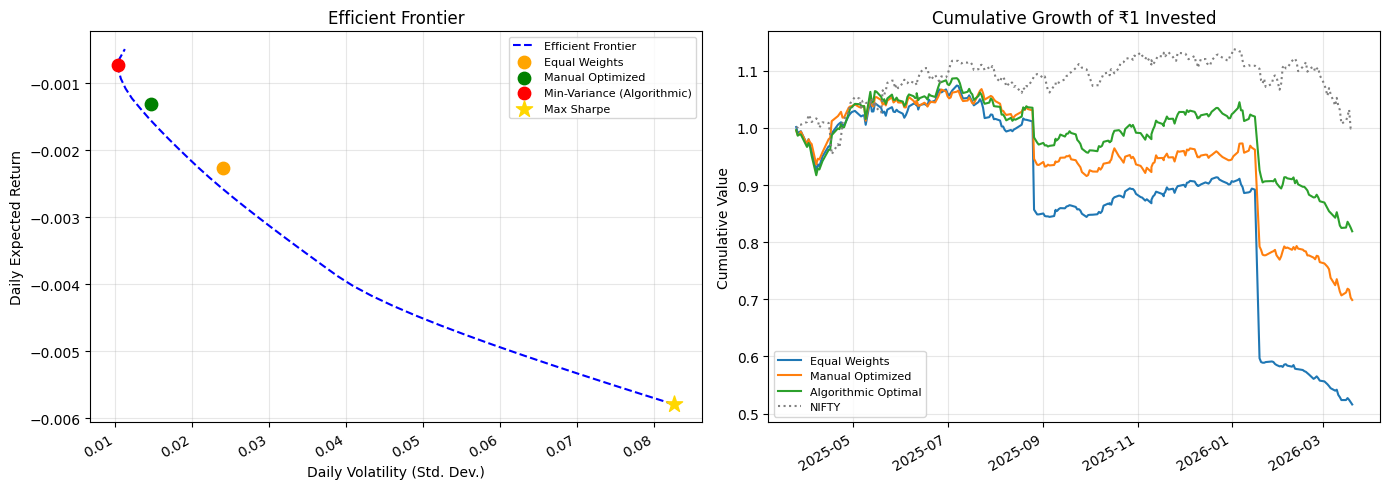

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Efficient frontier ---
axes[0].plot(frontier_df['Volatility'], frontier_df['Target Return'], 'b--', linewidth=1.5, label='Efficient Frontier')
axes[0].scatter(port_sd_eq, port_return_eq, color='orange', s=80, zorder=5, label='Equal Weights')
axes[0].scatter(port_sd_opt, port_return_opt, color='green', s=80, zorder=5, label='Manual Optimized')
axes[0].scatter(alg_sd, alg_return, color='red', s=80, zorder=5, label='Min-Variance (Algorithmic)')
axes[0].scatter(max_sharpe_vol, max_sharpe_return, color='gold', s=150, marker='*', zorder=6, label='Max Sharpe')
axes[0].set_xlabel('Daily Volatility (Std. Dev.)')
axes[0].set_ylabel('Daily Expected Return')
axes[0].set_title('Efficient Frontier')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# --- Cumulative growth ---
cum_eq = (1 + port_returns_eq).cumprod()
cum_opt = (1 + port_returns_opt).cumprod()
cum_alg = (1 + port_returns_alg).cumprod()
cum_nifty = (1 + log_returns['NIFTY']).cumprod()

axes[1].plot(cum_eq.index, cum_eq.values, label='Equal Weights')
axes[1].plot(cum_opt.index, cum_opt.values, label='Manual Optimized')
axes[1].plot(cum_alg.index, cum_alg.values, label='Algorithmic Optimal')
axes[1].plot(cum_nifty.index, cum_nifty.values, label='NIFTY', linestyle=':', color='gray')
axes[1].set_title('Cumulative Growth of ₹1 Invested')
axes[1].set_ylabel('Cumulative Value')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

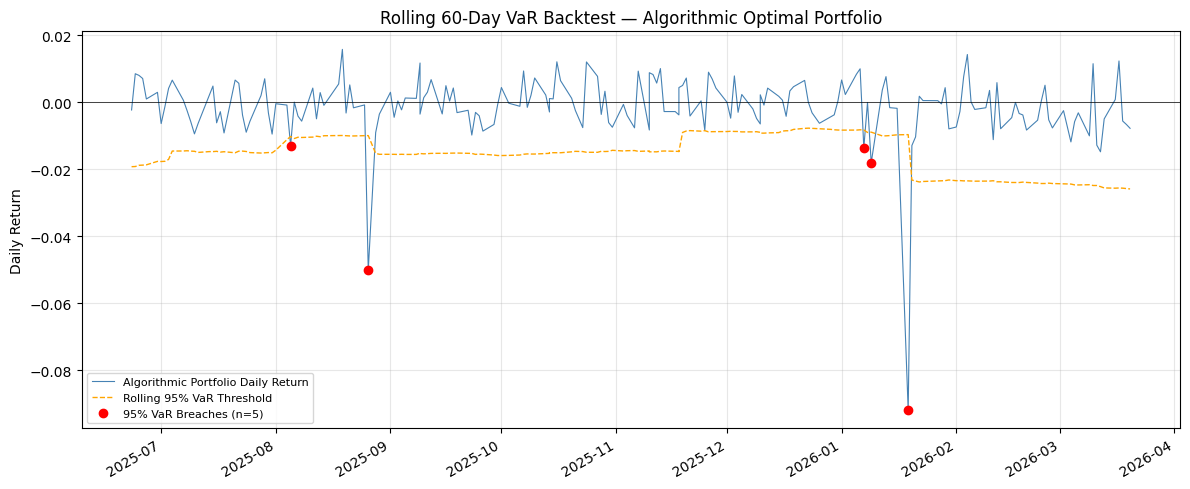

In [14]:
fig2, ax = plt.subplots(figsize=(12, 5))
ax.plot(backtest_df.index, backtest_df['Actual Return'], color='steelblue', linewidth=0.8,
        label='Algorithmic Portfolio Daily Return')
ax.plot(backtest_df.index, backtest_df['VaR 95%'], color='orange', linestyle='--', linewidth=1,
        label='Rolling 95% VaR Threshold')

breaches = backtest_df[backtest_df['Breach 95%']]
ax.scatter(breaches.index, breaches['Actual Return'], color='red', zorder=5,
           label=f'95% VaR Breaches (n={len(breaches)})')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Rolling 60-Day VaR Backtest, Algorithmic Optimal Portfolio')
ax.set_ylabel('Daily Return')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig2.autofmt_xdate()
plt.tight_layout()
plt.show()